TAREA DATA MINING 1


#1 CARGA DE DATOS

In [ ]:
import numpy as np
import pandas as pd
import plotnine as ptn
from plotnine import *
import sklearn as sk

In [ ]:
print("Numpy version:",np.__version__)
print("Pandas version:",pd.__version__)
print("Plotnine version:",ptn.__version__)
print("Sklearn version: ", sk.__version__)

#Importé directamente sklear porque no sabía qué era !sys honestamente y en vez de hacer pip install
#tiré eso de acá directo a colab que lo soporta.


Numpy version: 2.0.2
Pandas version: 2.2.2
Plotnine version: 0.14.5
Sklearn version:  1.6.1


In [ ]:
#Siempre uso head.() para ver que los datos se cargaron bien.
df = pd.read_csv("data/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#2 EDA Y LIMPIEZA  DE DATOS

In [ ]:
#Haremos EDA ahora para ver ciertas cosas que puedo obtener si es que los datos están raros, o hay cosas que no me cuadre:

print(df.isnull().sum())
print(df.duplicated().sum())
df.info()
df.describe()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#2.1 ELIMINAR COLUMNA CUSTOMER ID


In [ ]:
#Sacaré CustomerID ya que no es relevante para el análisis, solo es el número de los clientes que se evaluaron:

df = df.drop(columns=["CustomerID"])
df.head()


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#2.2 SOBRE GENRE Y DECISIÓN

Inicialmente se consideró incluir la variable género transformándola a formato binario. Sin embargo, dado que se trata de una variable categórica y el algoritmo K-Means utiliza distancias euclidianas sobre variables numéricas continuas, se decidió excluirla del análisis para evitar distorsiones en la formación de clusters. De este modo, el agrupamiento se realizó únicamente sobre edad, ingreso anual y puntaje de gasto, variables cuantitativas directamente relacionadas con el comportamiento del cliente.



In [ ]:
df = df.drop(columns=["Genre"])
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


#3 ESTANDARIZACION DE DATOS Y VISUALIZACION DE PLOTS

Se aplica estandarización (StandardScaler) porque K-Means calcula distancias euclidianas entre puntos. Sin estandarizar, Annual Income (rango 15-137) dominaría el cálculo de distancias sobre Spending Score (1-100) y Age (18-70) simplemente por tener una escala mayor, no por ser más importante. Al estandarizar, todas las variables contribuyen proporcionalmente al clustering.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Estandarizar columnas numéricas
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df) #acá aplicamos z=  (que es la estandarización)

#scaler.fit_transform()  # scaler es StandardScaler → estandariza números
#El mismo fit.transform() es porque su naturaleza cambia porque pertenece al objeto al que pertenece.
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head(7)

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
5,-1.209269,-1.662660,1.001596
6,-0.276302,-1.624491,-1.715913


In [ ]:
#Verifiquemos la Estandarización se haya hecho correctamente.
df_scaled.describe().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
25%,-0.72,-0.73,-0.60
50%,-0.20,0.04,-0.01
75%,0.73,0.67,0.89
max,2.24,2.92,1.89


## SEGUIMOS CON OBSERVACION DE DATOS

**Income vs Spending Score:**
Se observan visualmente 5 grupos diferenciados en el scatter plot,
lo que sugiere que estas dos variables serán las más relevantes
para el clustering.

**Age vs Spending Score:**
No se observan grupos claros — los datos están dispersos.
Age parece ser menos discriminante para segmentar clientes. Esto lo tendremos como observación.


**Conclusión:** Las variables más relevantes para el clustering
serán Annual Income y Spending Score. Sin embargo, usaremos age de todas formas ya que consideramos que es una variable a tomar en cuenta que no podemos dejar de lado y pueden influir en la discriminación y clusterización final. Age porque aporta separación entre clientes con perfiles económicos similares pero en distintas etapas de vida, lo cual tiene valor comercial para segmentar campañas.

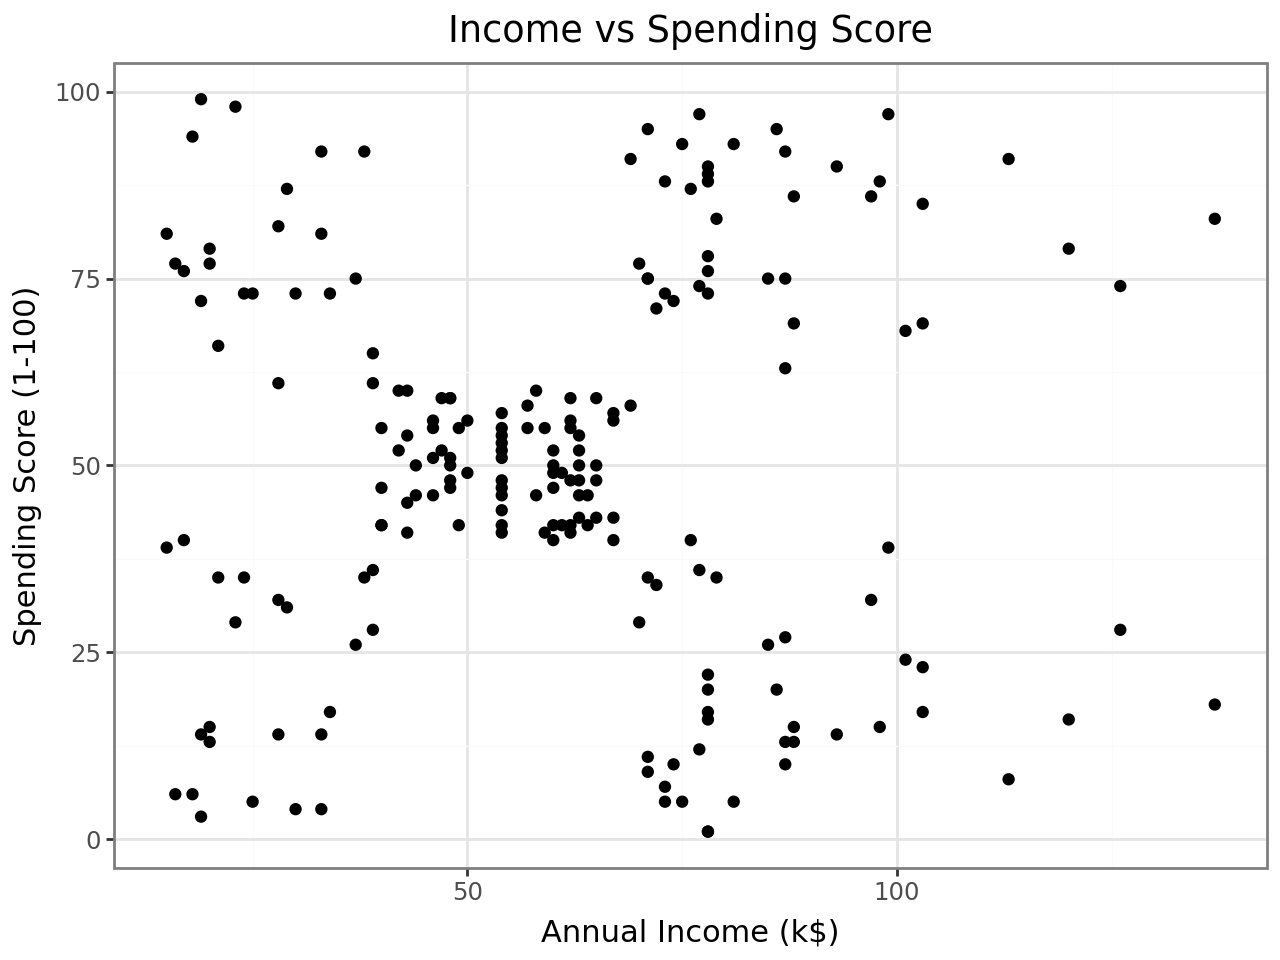

In [ ]:
# Distribución de Annual Income vs Spending Score
(ggplot(df)
 + aes(x="Annual Income (k$)", y="Spending Score (1-100)")
 + geom_point()
 + theme_bw()
 + labs(title="Income vs Spending Score"))

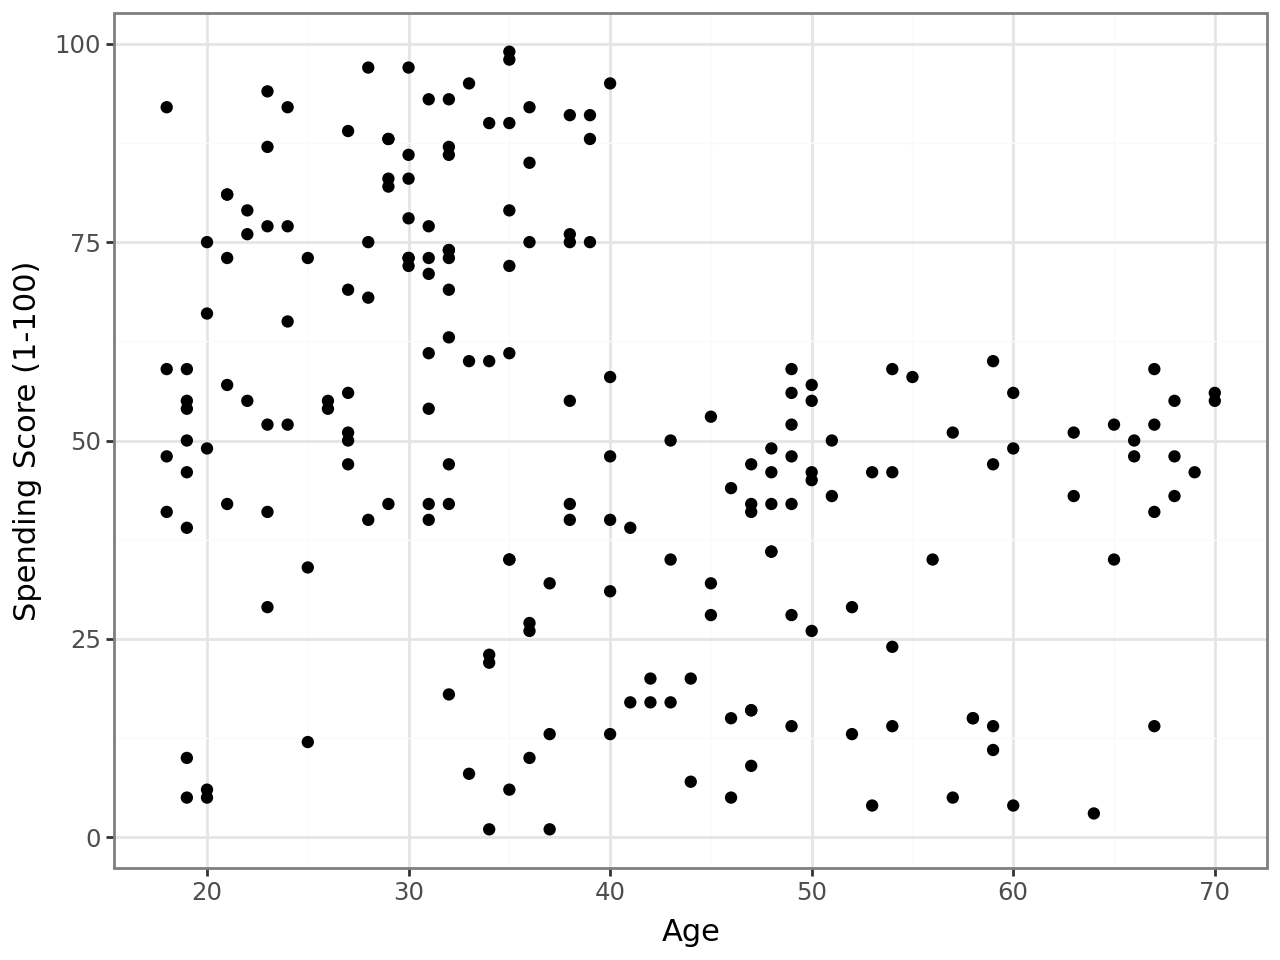

In [ ]:
# Distribución de Age vs Spending Score
(ggplot(df)
 + aes(x="Age", y="Spending Score (1-100)")
 + geom_point()
 + theme_bw())

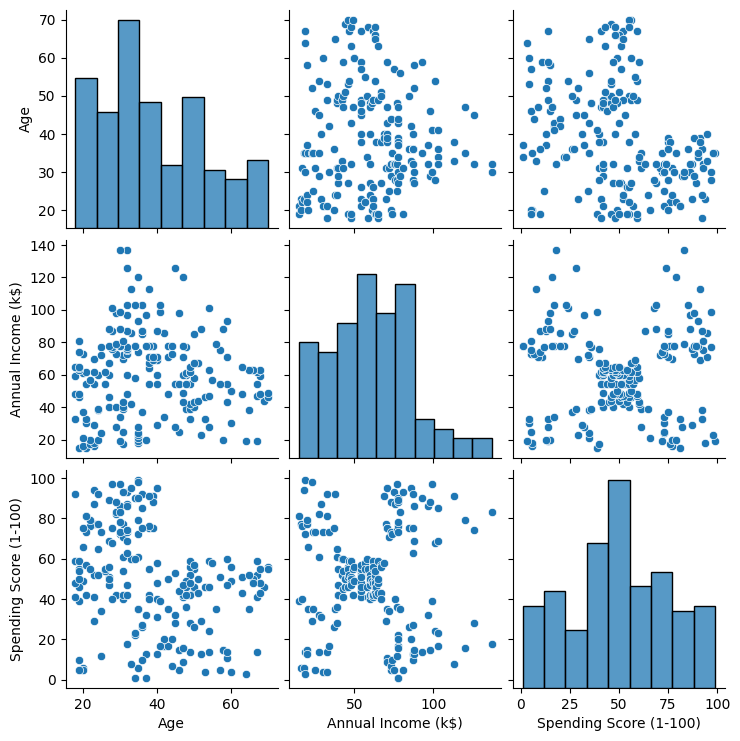

In [ ]:
import seaborn as sns
sns.pairplot(df)

#4 OUTLIERS

Se aplicó el algoritmo Local Outlier Factor (LOF) para detectar
valores atípicos en el dataset. LOF es un método basado en densidad
local compara la densidad de cada punto con la de sus vecinos.
Si un punto está en una zona mucho menos densa que sus vecinos,
se considera outlier.

Utilizamos n_neighbors = 20. El resultado fueron 4 outliers detectados (2% del dataset). Elegimos n_neighbors=20 tras probar la grilla {5, 10, 20, 30, 50}: los valores bajos (5, 10) detectan 5-6 outliers, probablemente inflados por ruido local, mientras que los altos (30, 50) pierden detecciones reales (hasta 0 con n=50) al diluir la densidad local.

Decidimos mantener los outliers porque representan perfiles de cliente plausibles y ningún valor supera ±3 desviaciones estándar en z-score (ver celda siguiente), por lo que no distorsionan significativamente los centroides de K-Means.

Para outliers: usamos TODOS los datos estandarizados (df_scaled)
Los outliers se detectan considerando todas las dimensiones juntas. Un punto puede ser normal en Income y normal en Age, pero raro en la combinación de ambos.
Para K-Means también usamos todos los datos (df_scaled)
El modelo usa las siguientes variables para calcular distancias. Age, Income y Spending Score.

In [ ]:
#Grilla que intentamos antes para ver como respondía el número de Outliers a diferentes valores de n.
#from sklearn.neighbors import LocalOutlierFactor

#for n in [5,10,20,30,50]:
  #lof = LocalOutlierFactor(n_neighbors=n)
  #labels = lof.fit_predict(df_scaled)
  #print(f"n_neighbors={n}: {(labels == -1).sum()} outliers")

n_neighbors=5: 5 outliers
n_neighbors=10: 6 outliers
n_neighbors=20: 4 outliers
n_neighbors=30: 3 outliers
n_neighbors=50: 0 outliers


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
# LOF compara densidad local de cada punto con sus k vecinos
# fit_predict retorna 1 (normal) o -1 (outlier)

lof = LocalOutlierFactor(n_neighbors=20)
outlier_labels = lof.fit_predict(df_scaled) #de nuevo escribimos fit, pero ahora predict

print(outlier_labels)
print(f"Outliers detectados: {(outlier_labels == -1).sum()}")
print(f"Puntos normales: {(outlier_labels == 1).sum()}")

[ 1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1 -1 -1]
Outliers detectados: 4
Puntos normales: 196


In [ ]:
print(df[outlier_labels == -1])

     Age  Annual Income (k$)  Spending Score (1-100)
2     20                  16                       6
197   32                 126                      74
198   32                 137                      18
199   30                 137                      83


In [ ]:
# Se decide mantener los outliers ya que con n_neighbors=20
# Se detectaron 4 puntos representando el 2% del dataset.
# del dataset. Eliminarlo no tendría impacto significativo
# y podrían ser clientes reales con ese perfil.

#################################################################

df_clean = df_scaled.copy()

# Verificar qué tan extremo es el outlier en términos de z-score
print("Valores estandarizados del outlier:")
print(df_clean[outlier_labels == -1])

# Ningún valor supera ±3 desviaciones estándar por lo que no es un outlier extremo
# (Un "Elon Musk" tendría valores de z > 10 en income, por ejemplo). Estadísticamente
# no está a más de 3 desviaciones estándar en ninguna dimensión.
#Por lo que leímos, z-scores +-3 no distorsionan los centroides al momento de aplicar kmeans significativamente

Valores estandarizados del outlier:
          Age  Annual Income (k$)  Spending Score (1-100)
2   -1.352802           -1.700830               -1.715913
197 -0.491602            2.497807                0.923953
198 -0.491602            2.917671               -1.250054
199 -0.635135            2.917671                1.273347


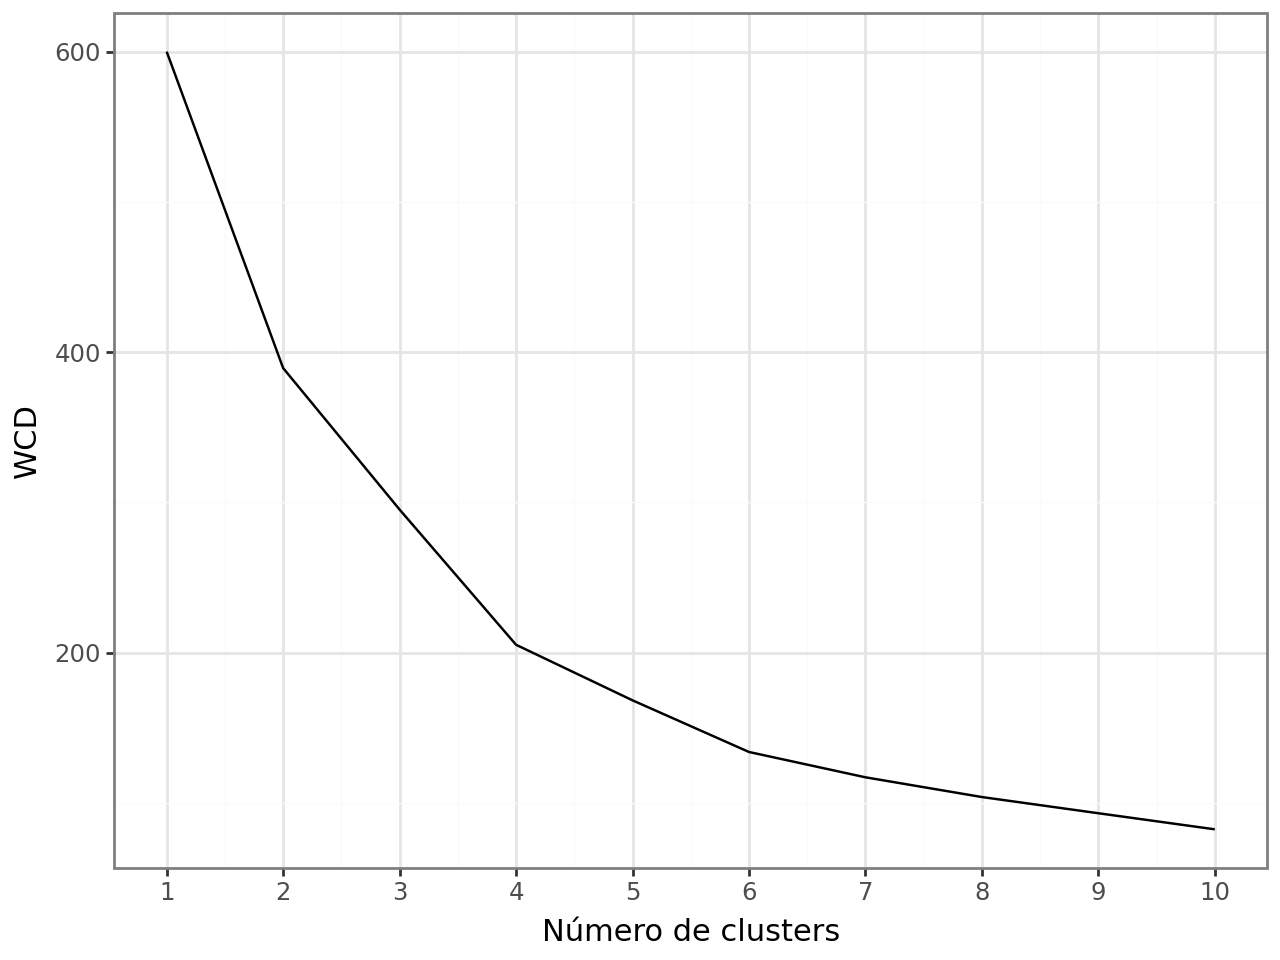

In [ ]:
from sklearn.cluster import KMeans

sse = []
numK = 11

# Probamos K desde 1 hasta 10 y guardamos el WCD de cada uno
for k in range(1, numK):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    # n_init=10: ejecuta K-Means 10 veces con distintos centroides iniciales
    # random_state=42: fija la semilla para resultados reproducibles
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_) #WCD = suma de distancias al centroide

# Hacemos la gráfica del codo (elbow method)
tempDF = pd.DataFrame(range(1, numK), columns=["numK"])
tempDF["sse"] = sse

(ggplot(tempDF) + aes(x="numK", y="sse") + theme_bw() + geom_line()
 + labs(x="Número de clusters", y="WCD")
 + scale_x_continuous(breaks=range(1, numK)))

#6 Etiquetado y Descripción de Clusters





Elegimos k=5 por tres motivos: el codo cae fuerte hasta k=4 y todavía se ve una baja apreciable en k=5 antes de aplanarse en k=6; en el scatter de Income vs Spending Score se distinguen a simple vista cinco grupos; y con k=5 quedan segmentos útiles para marketing, sobre todo el de "alto ingreso-bajo gasto", que con k=4 se mezclaría con otro y perderíamos esa distinción.

In [ ]:
# Se utilizó el método del codo junto a criterios visuales y de interpretabilidad
# comercial para elegir k=5 (ver justificación en celda anterior).


kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans.fit(df_scaled)

df["cluster"] = kmeans.labels_
print(df["cluster"].value_counts())

cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64


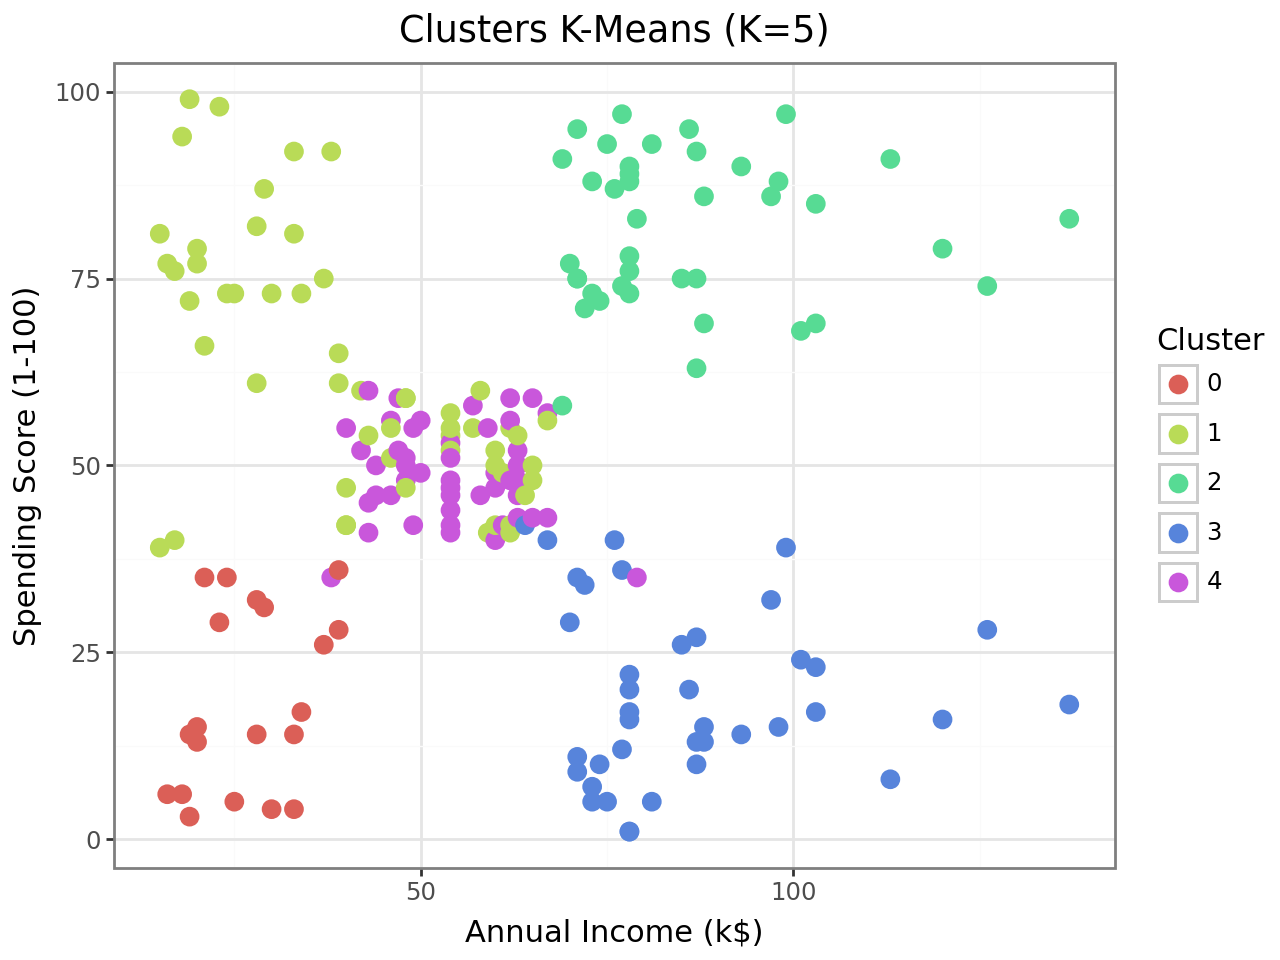

In [ ]:
(ggplot(df)
 + aes(x="Annual Income (k$)", y="Spending Score (1-100)", color="factor(cluster)")
 + geom_point(size=3)
 + theme_bw()
 + labs(title="Clusters K-Means (K=5)", color="Cluster"))

#Se graficaron las variables Annual Income y Spending Score porque son las más representativas para interpretar comercialmente los grupos encontrados.
#El objetivo es observar visualmente cómo se distribuyen los clientes según su ingreso y nivel de gasto,
#usando el color para distinguir el cluster asignado.

In [ ]:
# Ver estadísticas de cada cluster con los datos ORIGINALES (no escalados),
#porque los escalados tiene valores que no nos dicen nada interpretable.
#El escalado fue solo para que K-Means calcule distancias correctamente
# una vez que tenemos los clusters asignados, volvemos
#a los datos originales para interpretar quiénes son esos grupos.
print(df.groupby("cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1))

          Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                  
0        46.2                26.8                    18.4
1        25.2                41.1                    62.2
2        32.9                86.1                    81.5
3        39.9                86.1                    19.4
4        55.6                54.4                    48.9


#Descripción de los clusters:

1. CLUSTER 0: Edad media 46.2 años, bajo ingreso y spending score bajo, 18.4 Perfil conservador, probablemente compran solo lo necesario.

2. CLUSTER 1: Edad media 25.2 años, ingresos medios y spending score relativamente alto para su edad. Probablemente jóvenes adultos recién graduados que gastan bastante de su sueldo en compras.

3. CLUSTER 2: Clientes "Premiun": Edad 32.9 promedio, annual income 86.1 y spending score promedio 81.5: El sector más consumista de todos. Tienen edad que ronda los 30 y gastan mucho en consumo. Corresponde al sector "premiun" desde el punto de vista de un centro comercial.

4. CLUSTER 3: edad 39.9, anual icome 86.1 y media de spending score 19.4. Acá ocurre algo interesante respecto al cluster anterior, acá se debe focalizar una campaña de marketing agresivo dado que son clientes que ingresan mucho pero gastan poco, es decir: acá se puede obtener un buen margen de ganancias si se hacen las cosas bien.

5. CLUSTER 4: Edad media 55.6, ingresos medios altos, spending score medio. El grupo más "medio" de todos, básicamente adultos entrando a 3ra edad cuyo ingreso se sitúa en una parte media-alta y sus gastos corresponden también a un valor medio, no gastan mucho, pero tampoco no lo hace. Es un grupo susceptible a campañas de marketing quizás, aunque eso quedará a escrutinio propio.

etiqueta
Ingreso moderado - alto gasto          54
Ingreso medio - gasto medio            47
Premium (alto ingreso - alto gasto)    40
Alto ingreso - bajo gasto              39
Bajo ingreso - bajo gasto              20
Name: count, dtype: int64


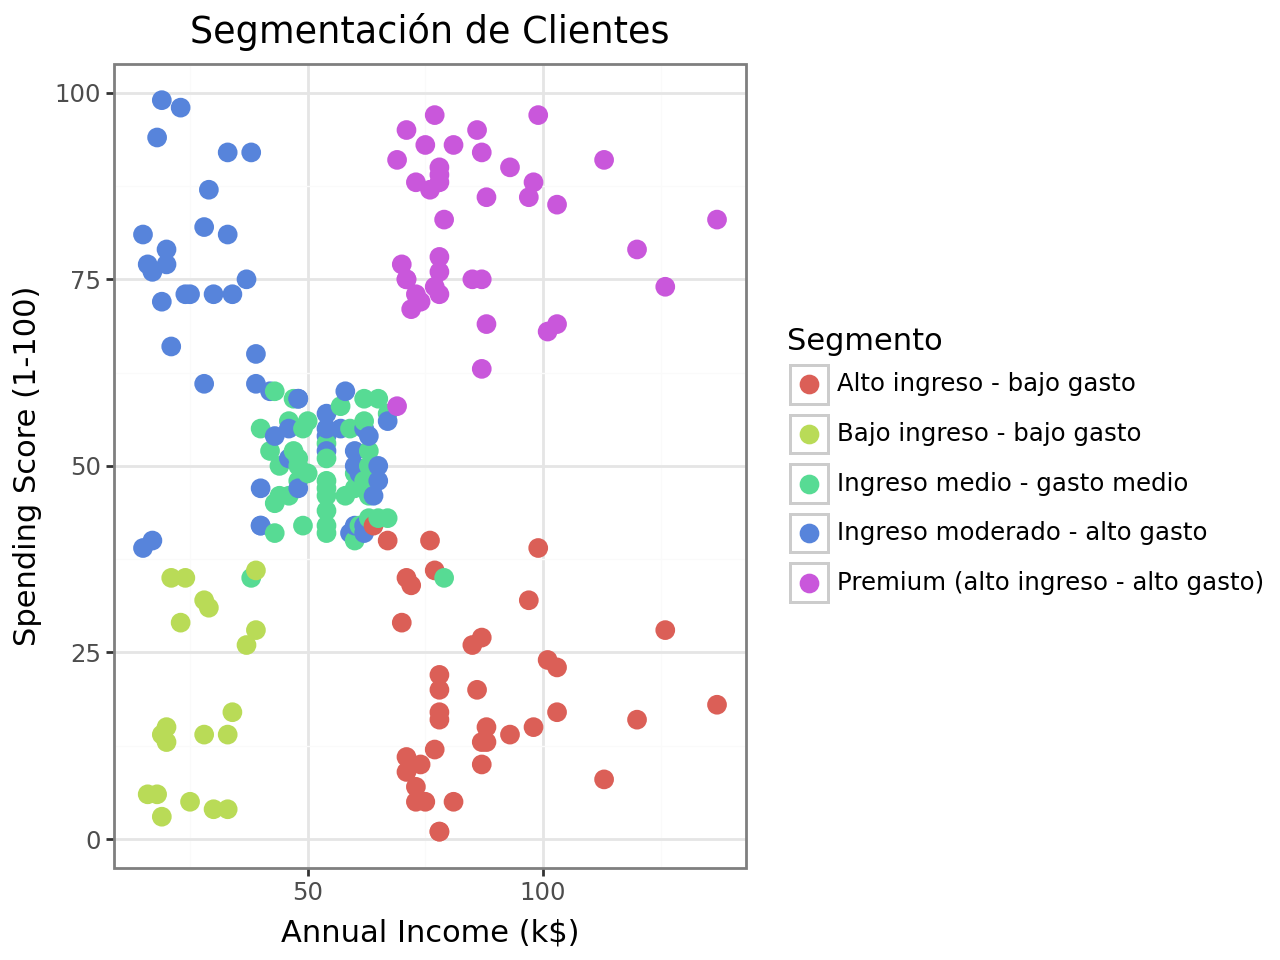

In [ ]:
etiquetas = {
    0: "Bajo ingreso - bajo gasto",
    1: "Ingreso moderado - alto gasto",
    2: "Premium (alto ingreso - alto gasto)",
    3: "Alto ingreso - bajo gasto",
    4: "Ingreso medio - gasto medio"
}

df["etiqueta"] = df["cluster"].map(etiquetas)
print(df["etiqueta"].value_counts())

(ggplot(df)
 + aes(x="Annual Income (k$)", y="Spending Score (1-100)", color="etiqueta")
 + geom_point(size=3)
 + theme_bw()
 + labs(title="Segmentación de Clientes", color="Segmento"))